In [10]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.2.6


In [11]:
ginkgo_path = "../data/gdpa1_v1.0_20250502.xlsx"

sequences_df = pd.read_excel(ginkgo_path, sheet_name = 'Sequences')
assay_df = pd.read_excel(ginkgo_path, sheet_name = 'Assay Data - average')

if sequences_df is not None and assay_df is not None:
    print("Dataset loaded successfully!")

    # Print shape of the datasets
    print(f"Sequences shape: {sequences_df.shape}")
    print(f"Assay data shape: {assay_df.shape}")

    # Print column names and sample data for both DataFrames
    print("\n=== Sequences DataFrame ===")
    print(f"Columns: {list(sequences_df.columns)}")
    print(f"Sample sequences:")
    print(sequences_df[['antibody_id', 'antibody_name', 'vh_protein_sequence', 'vl_protein_sequence']].head())

    print("\n=== Assay Data DataFrame ===")
    print(f"Columns: {list(assay_df.columns)}")
    print(f"Sample assay data:")
    print(assay_df[['antibody_id', 'antibody_name']].head())

Dataset loaded successfully!
Sequences shape: (246, 24)
Assay data shape: (246, 55)

=== Sequences DataFrame ===
Columns: ['antibody_id', 'antibody_name', 'hc_subtype', 'lc_subtype', 'highest_clinical_trial_asof_feb2025', 'est_status_asof_feb2025', 'vh_protein_sequence', 'hc_protein_sequence_production_batch_1', 'hc_dna_sequence_production_batch_1', 'hc_protein_sequence_production_batch_2', 'hc_dna_sequence_production_batch_2', 'hc_protein_sequence_production_batch_3', 'hc_dna_sequence_production_batch_3', 'hc_protein_sequence_production_batch_4', 'hc dna sequence_production batch_4', 'vl_protein_sequence', 'lc_protein_sequence_production_batch_1', 'lc_dna_sequence_production_batch_1', 'lc_protein_sequence_production_batch_2', 'lc_dna_sequence_production_batch_2', 'lc_protein_sequence_production_batch_3', 'lc_dna_sequence_production_batch_3', 'lc_protein sequence_production batch_4', 'lc_dna sequence_production batch_4']
Sample sequences:
  antibody_id antibody_name  \
0   GDPa1-001   

In [12]:
# Isolate property columns for analysis

TARGET_PROPERTIES = {
    'Thermostability (Tm2)': 'tm2_nanodsf_avg',
    'Hydrophobicity (HIC)': 'hic_rt_avg',
    'Self-association (AC-SINS)': 'acsins_dLmax_ph7.4_avg',
    'Polyreactivity (CHO)': 'polyreactivity_prscore_cho_avg', 
    'Titer': 'normalized_titer_productionbatch1_avg',
}

def clean_dataset(sequences_df, assay_df):    
    sequence_columns = ['antibody_id', 'antibody_name', 'hc_subtype', 'lc_subtype', 'vh_protein_sequence', 'vl_protein_sequence']
    clean_df = sequences_df[sequence_columns].copy()
    
    target_cols = ['antibody_id'] + list(TARGET_PROPERTIES.values())
    targets_df = assay_df[target_cols].copy()
    
    merged_df = clean_df.merge(targets_df, on = 'antibody_id', how = 'inner')
    
    return merged_df

# Create the clean dataset
df = clean_dataset(sequences_df, assay_df)

print(f"Clean dataset shape: {df.shape}")
print(f"Target properties: {list(TARGET_PROPERTIES.keys())}")

# Display sample data
print("\n=== Clean Dataset ===")
print(f'columns: {df.columns}\n')
display_cols = ['antibody_id', 'antibody_name', 'hc_subtype', 'lc_subtype'] + list(TARGET_PROPERTIES.values())
print(df[display_cols].head())

# Check for missing values
print("\n=== Missing Values Analysis ===")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


Clean dataset shape: (246, 11)
Target properties: ['Thermostability (Tm2)', 'Hydrophobicity (HIC)', 'Self-association (AC-SINS)', 'Polyreactivity (CHO)', 'Titer']

=== Clean Dataset ===
columns: Index(['antibody_id', 'antibody_name', 'hc_subtype', 'lc_subtype',
       'vh_protein_sequence', 'vl_protein_sequence', 'tm2_nanodsf_avg',
       'hic_rt_avg', 'acsins_dLmax_ph7.4_avg',
       'polyreactivity_prscore_cho_avg',
       'normalized_titer_productionbatch1_avg'],
      dtype='object')

  antibody_id antibody_name hc_subtype lc_subtype  tm2_nanodsf_avg  \
0   GDPa1-001    abagovomab       IgG1      Kappa            83.12   
1   GDPa1-002    abituzumab       IgG2      Kappa            80.40   
2   GDPa1-003   abrezekimab       IgG4      Kappa            85.12   
3   GDPa1-004     abrilumab       IgG2      Kappa            75.85   
4   GDPa1-005    adalimumab       IgG1      Kappa            84.96   

   hic_rt_avg  acsins_dLmax_ph7.4_avg  polyreactivity_prscore_cho_avg  \
0        2.5

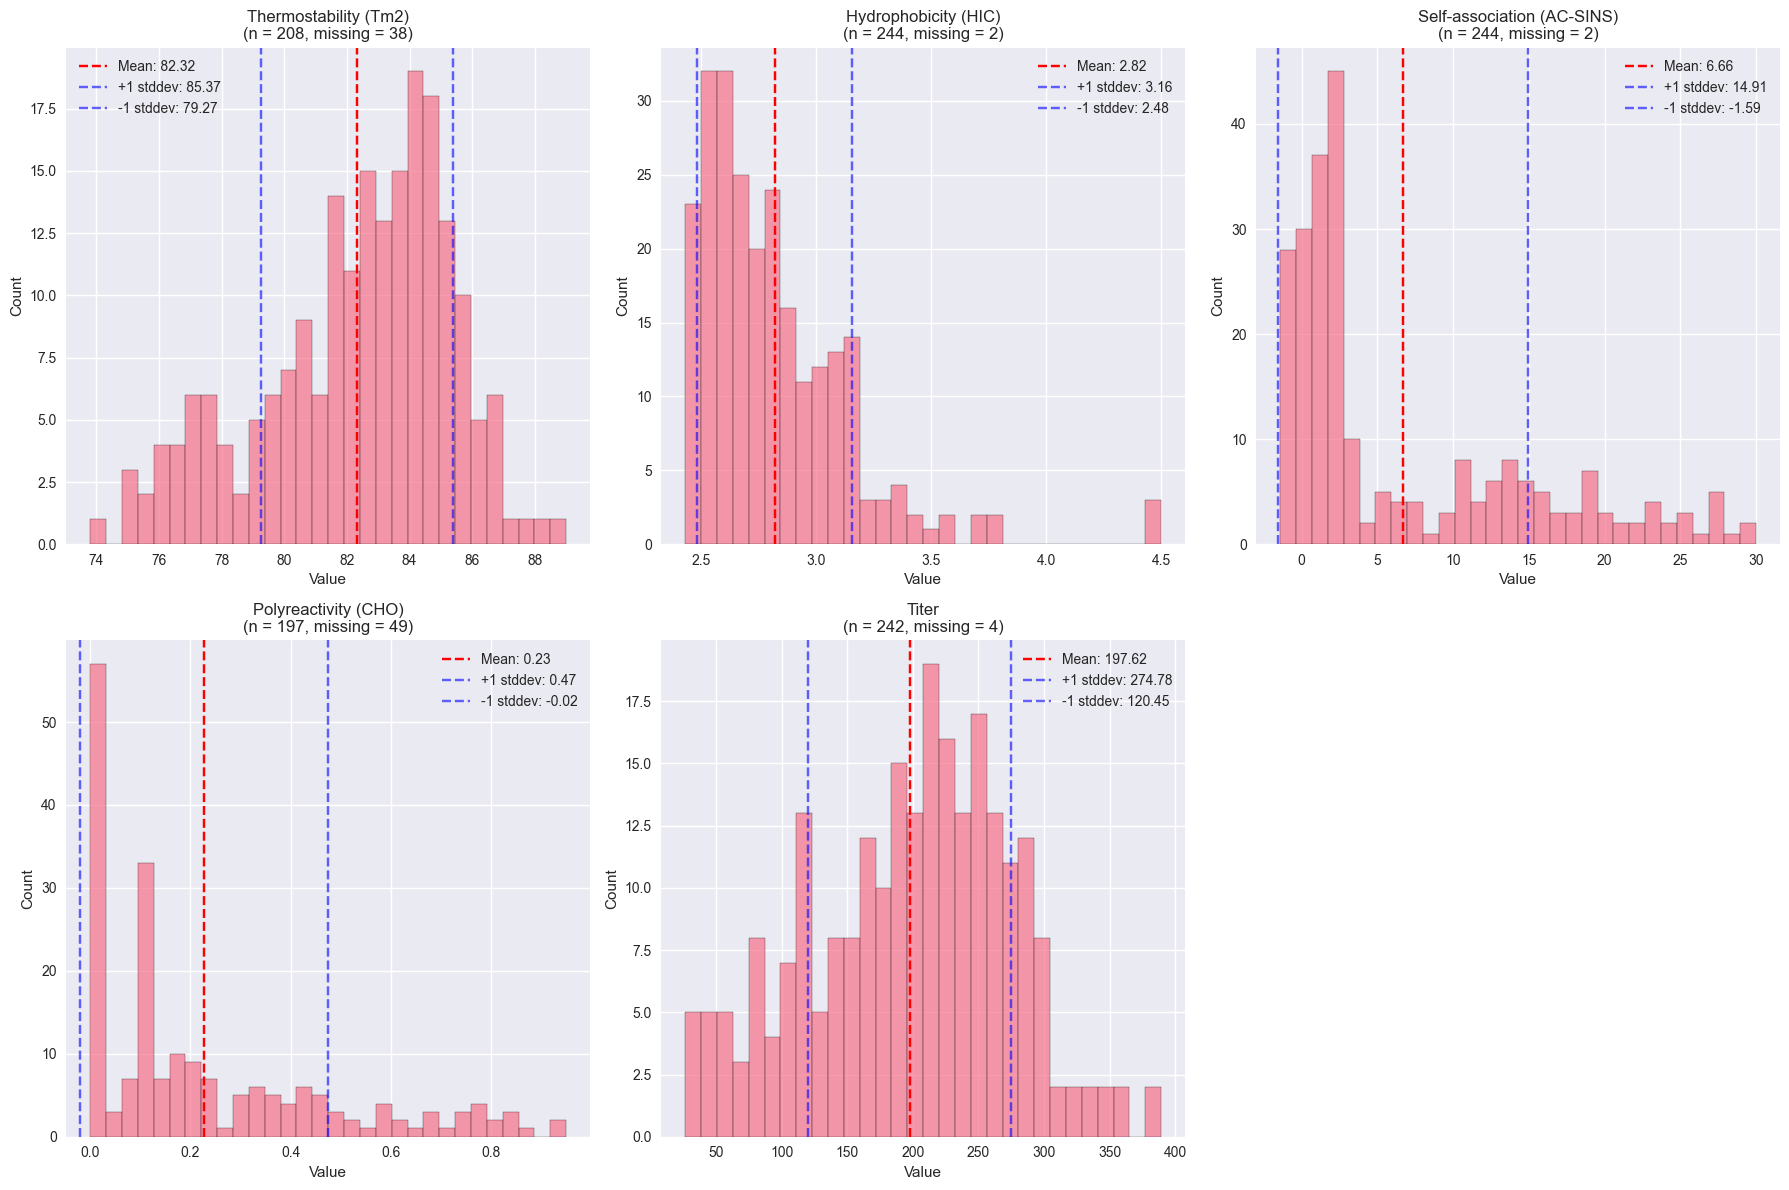

In [13]:
# Visualize data distributions for each target property

fig, axes = plt.subplots(2, 3, figsize = (18, 12))
axes = axes.ravel()

for i, (property_name, col_name) in enumerate(TARGET_PROPERTIES.items()):
    ax = axes[i]
    
    data = df[col_name].dropna() # Ensure non-null values
    
    if len(data) > 0:
        ax.hist(data, bins = 30, alpha = 0.7, edgecolor = 'black')
        ax.set_title(f'{property_name}\n(n = {len(data)}, missing = {df[col_name].isnull().sum()})')
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')
        
        # Add mean and stddev lines
        mean_val = data.mean()
        std_dev = data.std()
        ax.axvline(mean_val, color = 'red', linestyle = '--', label = f'Mean: {mean_val:.2f}')
        ax.axvline(mean_val + std_dev, color = 'blue', linestyle = '--', alpha = 0.6, label = f'+1 stddev: {mean_val + std_dev:.2f}')
        ax.axvline(mean_val - std_dev, color = 'blue', linestyle = '--', alpha = 0.6, label = f'-1 stddev: {mean_val - std_dev:.2f}')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No data available', ha = 'center', va = 'center', transform = ax.transAxes)
        ax.set_title(f'{property_name}\n(No data)')

# Hide the last subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show() 

In [14]:
# Investigate summary statistics for each target property

print("=== Target Properties Summary Statistics ===")
for prop_name, col_name in TARGET_PROPERTIES.items():
    data = df[col_name].dropna()
    if len(data) > 0:
        print(f"\n{prop_name}:")
        print(f"  Count: {len(data)}")
        print(f"  Missing: {df[col_name].isnull().sum()}")
        print(f"  Mean: {data.mean():.3f}")
        print(f"  Std: {data.std():.3f}")
        print(f"  Min: {data.min():.3f}")
        print(f"  Max: {data.max():.3f}")
        print(f"  Range: {data.max() - data.min():.3f}")
    else:
        print(f"\n{prop_name}: No data available")

=== Target Properties Summary Statistics ===

Thermostability (Tm2):
  Count: 208
  Missing: 38
  Mean: 82.323
  Std: 3.051
  Min: 73.810
  Max: 89.000
  Range: 15.190

Hydrophobicity (HIC):
  Count: 244
  Missing: 2
  Mean: 2.818
  Std: 0.337
  Min: 2.430
  Max: 4.500
  Range: 2.070

Self-association (AC-SINS):
  Count: 244
  Missing: 2
  Mean: 6.658
  Std: 8.248
  Min: -1.420
  Max: 30.000
  Range: 31.420

Polyreactivity (CHO):
  Count: 197
  Missing: 49
  Mean: 0.227
  Std: 0.247
  Min: 0.000
  Max: 0.950
  Range: 0.950

Titer:
  Count: 242
  Missing: 4
  Mean: 197.618
  Std: 77.163
  Min: 26.530
  Max: 389.360
  Range: 362.830


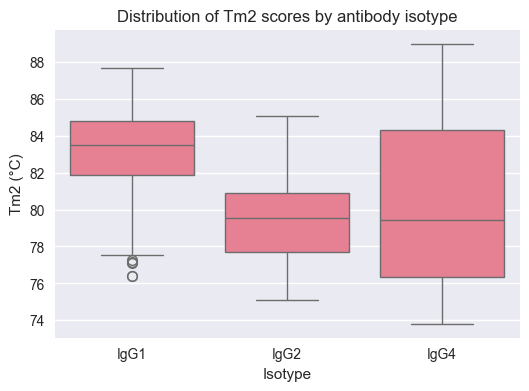

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hc_subtype", y = TARGET_PROPERTIES['Thermostability (Tm2)'])
plt.title("Distribution of Tm2 scores by antibody isotype")
plt.xlabel("Isotype")
plt.ylabel("Tm2 (°C)")
plt.show()

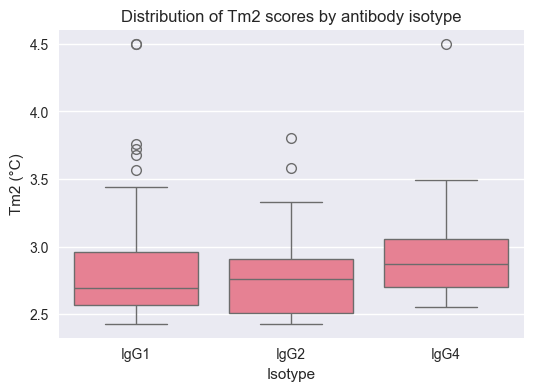

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hc_subtype", y = TARGET_PROPERTIES['Hydrophobicity (HIC)'])
plt.title("Distribution of HIC scores by antibody isotype")
plt.xlabel("Isotype")
plt.ylabel("HIC")
plt.show()

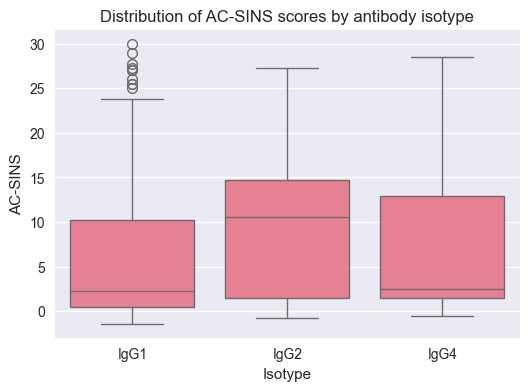

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hc_subtype", y = TARGET_PROPERTIES['Self-association (AC-SINS)'])
plt.title("Distribution of AC-SINS scores by antibody isotype")
plt.xlabel("Isotype")
plt.ylabel("AC-SINS")
plt.show()

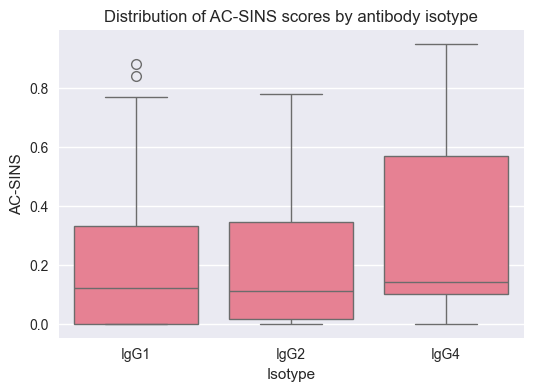

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hc_subtype", y = TARGET_PROPERTIES['Polyreactivity (CHO)'])
plt.title("Distribution of Polyreactivity (CHO) scores by antibody isotype")
plt.xlabel("Isotype")
plt.ylabel("Polyreactivity (CHO)")
plt.show()

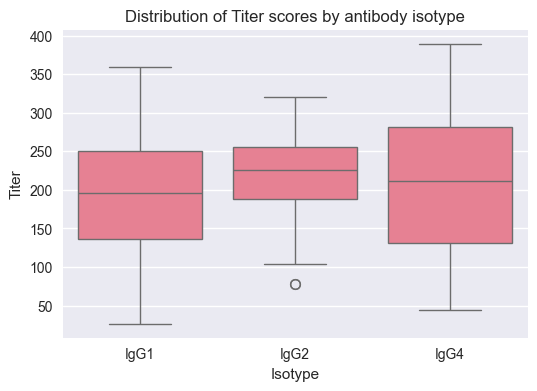

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hc_subtype", y = TARGET_PROPERTIES['Titer'])
plt.title("Distribution of Titer scores by antibody isotype")
plt.xlabel("Isotype")
plt.ylabel("Titer")
plt.show()